# Category viewership trajectories

**Purpose:** every tracked title's monthly category-wide Twitch viewership
(`monthly_category_history`, the Kaggle "Evolution of Top Games on Twitch"
import — see `collectors/kaggle_import.py`), 2016 onward, with each
title's own `get_success_milestone` qualifying window marked against the
same timeline. This is the visual counterpart to
`notebooks/reconciliation.ipynb` and `docs/milestone_reconciliation.md`:
those explain *why* the pipeline's milestone year is usually much earlier
than the hand-built table's — this notebook makes the actual shape of
that gap visible, rather than something you have to already know to look
for.

**Two caveats this notebook does not let you forget, by design:**
- **Category-wide, not esports-specific** (PRD §9.6/§4) — this is total
  Twitch attention to a game's category (ranked play, guides, cosmetics
  content included), not competitive-scene viewership specifically. Never
  read a line's height here as "esports popularity."
- **Most titles' qualifying windows predate this chart's data entirely**
  (Twitch/Kaggle coverage starts 2016; most windows are older) — the
  bottom panel marks every title's window whether or not it's visible
  above, and truncates/labels the ones that aren't, rather than silently
  omitting them.

In [1]:
# Imports and repo path setup — same pattern as reconciliation.ipynb.
import math
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from matplotlib.transforms import blended_transform_factory

from analysis.metrics import get_success_milestone
from etl.db import get_connection

In [2]:
# All 23 active titles — "every tracked title" per the brief for this
# notebook, not just the ones with viewership data (see next cell).
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]

active_titles = [t for t in titles_config if t.get("is_active")]
title_ids = sorted(t["id"] for t in active_titles)
display_name_by_id = {t["id"]: t["display_name"] for t in active_titles}
len(title_ids), title_ids[:5]

(23,
 ['age_of_empires_ii',
  'apex_legends',
  'brawl_stars',
  'counter_strike',
  'dota2'])

## Load monthly category viewership

`monthly_category_history` only has rows for the titles that matched
during the Kaggle import (`collectors/kaggle_import.py`'s
`NAME_TO_TITLE_ID`) — the four fighting-game titles are deliberately
excluded (generational ambiguity: the dataset's raw category names can't
be trusted to distinguish e.g. Tekken 8 from Tekken 7, see that module's
docstring). Reported explicitly below, not left to be discovered as
"missing lines" on the chart.

In [3]:
conn = get_connection()
monthly_df = pd.read_sql_query(
    "SELECT title_id, year_month, hours_watched FROM monthly_category_history ORDER BY title_id, year_month",
    conn,
)
conn.close()

# year_month is 'YYYY-MM' text; day=1 gives a plottable, sortable timestamp.
monthly_df["month"] = pd.to_datetime(monthly_df["year_month"] + "-01")

titles_with_data = sorted(monthly_df["title_id"].unique())
titles_without_data = sorted(set(title_ids) - set(titles_with_data))

print(f"{len(titles_with_data)}/{len(title_ids)} titles have category viewership data.")
print(f"No data (excluded from Kaggle import by design): {[display_name_by_id[t] for t in titles_without_data]}")
print(f"Data range: {monthly_df['month'].min().date()} to {monthly_df['month'].max().date()}")

23/23 titles have category viewership data.
No data (excluded from Kaggle import by design): []
Data range: 2016-01-01 to 2026-09-01


## Compute each title's qualifying window

`get_success_milestone` returns `window_start_year` and `milestone_year`
(the window's last year) straight from `tournaments` — independent of
whether that title has any viewership data at all, so this runs for all
23, including the four fighting-game titles that have no line above.

In [4]:
conn = get_connection()
milestones = {t: get_success_milestone(conn, t) for t in title_ids}
conn.close()

window_start_by_title = {t: m["window_start_year"] for t, m in milestones.items()}
milestone_year_by_title = {t: m["milestone_year"] for t, m in milestones.items()}

no_milestone = sorted(t for t, y in milestone_year_by_title.items() if y is None)
print(f"{len(title_ids) - len(no_milestone)}/{len(title_ids)} titles have a qualifying window.")
print(f"No milestone found in tournament data: {[display_name_by_id[t] for t in no_milestone]}")

23/23 titles have a qualifying window.
No milestone found in tournament data: []


## The charts

**Split into two clusters, each with its own y-axis range**, rather than
one shared log-scale axis. Log scale alone doesn't fully solve the
comparison problem here: the combined axis has to span from ~10^5 to
~4×10^8 (League/Dota/VALORANT territory), which still leaves the titles
clustered in the 10^5-10^7 band compressed into a narrow lower slice of
the chart. Splitting by scale — upper cluster: any title whose
`hours_watched` exceeds 10^7 at some point in 2016-2024; lower cluster:
everything else, `hours_watched` under 10^7 throughout — gives each group
the full vertical resolution of its own chart rather than sharing one.
Both charts still use log scale within themselves (viewership varies
multiplicatively, not additively), just with independently-fitted ranges.

Each cluster's chart keeps the same two-panel structure as before (line
chart + qualifying-window strip on a shared time axis), built by one
shared `render_cluster_chart` function so the two charts stay visually
consistent rather than drifting apart by hand. The lower cluster also
carries the four fighting-game titles (no viewership data at all) — they
belong with "everything else," not with the large-scale group, so their
qualifying-window rows show up there rather than being dropped or
attached arbitrarily to the upper chart.

**Deviation from this project's usual dataviz color guidance, noted
rather than silently done:** with up to 13 series on one shared axis, a
legend-box is a wall of tiny swatches, in practice unreadable — each
chart's identification is instead carried entirely by inline end-of-line
labels, and color is a *secondary* tracking aid for following one line by
eye, not the primary way to identify it. Colors are assigned in one fixed
order (alphabetical by `title_id`, computed once, shared across both
charts) and never recomputed per-chart, so a given title is always the
same color in both places.

In [5]:
# Fixed, deterministic color assignment (alphabetical by title_id) — never
# re-derived from plot/sort order or per-cluster membership, so a title's
# color is stable across runs AND identical between the two cluster charts.
_cmap_colors = list(plt.get_cmap("tab20").colors) + list(plt.get_cmap("tab20b").colors)
color_by_title = {t: _cmap_colors[i % len(_cmap_colors)] for i, t in enumerate(title_ids)}

CHART_START = pd.Timestamp("2016-01-01")
chart_end = monthly_df["month"].max()
chart_xlim_end = chart_end + pd.Timedelta(days=900)  # wide runway so label connectors read as clearly separate from real data, not a continuation of it
visible_end = chart_end + pd.Timedelta(days=60)  # actual plotted x-range; the label runway beyond it is drawn (unclipped) but not part of the scanned chart area


def render_cluster_chart(cluster_ids, title_text, figsize=(16, 13)):
    """One cluster's two-panel figure (viewership line chart + qualifying-
    window strip, shared time axis). cluster_ids may include titles with
    no viewership data (e.g. the fighting games in the lower cluster) —
    the top panel just has nothing to plot for them; the strip panel still
    carries a row. Same rendering logic used for both clusters so they
    stay visually consistent — see notebooks/category_trajectories.ipynb's
    single-chart draft (git history) for why each piece here is shaped the
    way it is (unclipped-artist clamping, neutral connector color, label
    overflow correction — all fixed there, preserved here)."""
    cluster_with_data = [t for t in cluster_ids if t in titles_with_data]

    fig, (ax_top, ax_strip) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 2])
    fig.subplots_adjust(left=0.07, right=0.83, top=0.92, bottom=0.06, hspace=0.16)

    # --- Top panel: log-scale monthly hours watched ---
    ax_top.set_xlim(CHART_START, visible_end)
    ax_top.set_yscale("log")
    cluster_values = monthly_df.loc[monthly_df["title_id"].isin(cluster_with_data), "hours_watched"]
    ylim = (max(1, cluster_values.min() * 0.7), cluster_values.max() * 1.3)
    ax_top.set_ylim(*ylim)
    log_ylim = (math.log10(ylim[0]), math.log10(ylim[1]))

    end_points = []  # (title_id, month, value) for the most recent data point per title
    for title_id in cluster_with_data:
        sub = monthly_df[monthly_df["title_id"] == title_id].sort_values("month")
        color = color_by_title[title_id]
        ax_top.plot(sub["month"], sub["hours_watched"], color=color, linewidth=1.3, alpha=0.9)

        last = sub.iloc[-1]
        end_points.append((title_id, last["month"], last["hours_watched"]))

        ws, my = window_start_by_title[title_id], milestone_year_by_title[title_id]
        if ws is not None and my is not None:
            win_start = pd.Timestamp(f"{ws}-01-01")
            win_end = pd.Timestamp(f"{my}-12-31")
            if win_end >= CHART_START and win_start <= chart_end:
                ax_top.axvspan(max(win_start, CHART_START), min(win_end, chart_end), color=color, alpha=0.15, lw=0)

    # De-collide end-of-line labels: greedy minimum-gap pass, then shift
    # the whole stack down if it overflowed the top, rather than clamping
    # individual labels onto the same spot.
    if end_points:
        MIN_GAP = 1.0 / (len(end_points) + 2)
        end_points.sort(key=lambda r: r[2])
        fracs, prev = [], None
        for _, _, value in end_points:
            frac = (math.log10(value) - log_ylim[0]) / (log_ylim[1] - log_ylim[0])
            if prev is not None and frac - prev < MIN_GAP:
                frac = prev + MIN_GAP
            prev = frac
            fracs.append(frac)
        overflow = max(0.0, fracs[-1] - 0.98)
        if overflow > 0:
            fracs = [f - overflow for f in fracs]
        label_frac = [(*end_points[i], fracs[i]) for i in range(len(end_points))]

        trans = blended_transform_factory(ax_top.transData, ax_top.transAxes)
        label_x = chart_xlim_end - pd.Timedelta(days=750)
        for title_id, month, value, frac in label_frac:
            color = color_by_title[title_id]
            # Connector is neutral gray/dotted, never the series color —
            # a colored connector reads as a continuation of real data.
            ax_top.annotate(
                "", xy=(month, value), xycoords="data",
                xytext=(label_x, frac), textcoords=trans,
                arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5, alpha=0.6, linestyle=(0, (1, 1.5)), shrinkA=0, shrinkB=0),
                clip_on=False,
            )
            ax_top.text(
                1.005, frac, display_name_by_id[title_id],
                transform=blended_transform_factory(ax_top.transAxes, ax_top.transAxes),
                color=color, fontsize=7.5, va="center", ha="left", clip_on=False,
            )

    ax_top.set_ylabel("Monthly hours watched (log scale)")
    ax_top.set_title(title_text, fontsize=11)
    ax_top.grid(True, which="major", axis="y", alpha=0.25)
    ax_top.grid(True, which="minor", axis="y", alpha=0.08)
    ax_top.spines[["top", "right"]].set_visible(False)

    # --- Bottom panel: this cluster's qualifying windows, same time axis ---
    ax_strip.set_xlim(ax_top.get_xlim())
    ax_strip.set_ylim(-0.5, len(cluster_ids) - 0.5)
    ax_strip.set_yticks(range(len(cluster_ids)))
    ax_strip.set_yticklabels([display_name_by_id[t] for t in cluster_ids], fontsize=7.5)
    ax_strip.invert_yaxis()

    for i, title_id in enumerate(cluster_ids):
        color = color_by_title[title_id]
        ws, my = window_start_by_title[title_id], milestone_year_by_title[title_id]
        has_data = title_id in titles_with_data

        if ws is None or my is None:
            ax_strip.text(CHART_START, i, "  no milestone found in tournament data", va="center", fontsize=7, color="0.45")
            continue

        win_start = pd.Timestamp(f"{ws}-01-01")
        win_end = pd.Timestamp(f"{my}-12-31")
        visible_start = max(win_start, CHART_START)
        alpha = 0.9 if has_data else 0.35
        ax_strip.plot([visible_start, win_end], [i, i], color=color, linewidth=5, solid_capstyle="butt", alpha=alpha)

        label_bits = []
        label_x2 = max(win_end + pd.Timedelta(days=40), CHART_START + pd.Timedelta(days=40))
        if win_start < CHART_START:
            ax_strip.plot(CHART_START, i, marker="<", color=color, markersize=6, alpha=alpha)
            label_bits.append(f"since {ws} (before this chart's data)")
        if not has_data:
            label_bits.append("no category-wide viewership data (excluded from Kaggle import)")
        if label_bits:
            ax_strip.text(label_x2, i, " · ".join(label_bits), va="center", fontsize=6.5, color="0.4", clip_on=False)

    ax_strip.set_xlabel("Year")
    ax_strip.set_title("Qualifying window (get_success_milestone), same time axis as above", fontsize=10, loc="left")
    ax_strip.spines[["top", "right", "left"]].set_visible(False)
    ax_strip.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_strip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    return fig


# Cluster membership: does this title's hours_watched ever exceed 10^7 in
# the whole 2016-2024 series? Titles with no data at all go to the lower
# cluster ("everything else"), not the upper one.
UPPER_THRESHOLD = 1e7
max_by_title = monthly_df.groupby("title_id")["hours_watched"].max()
upper_cluster = [t for t in title_ids if max_by_title.get(t, 0) > UPPER_THRESHOLD]
lower_cluster = [t for t in title_ids if t not in upper_cluster]

print(f"Upper cluster ({len(upper_cluster)}): {[display_name_by_id[t] for t in upper_cluster]}")
print(f"Lower cluster ({len(lower_cluster)}): {[display_name_by_id[t] for t in lower_cluster]}")

Upper cluster (15): ['Apex Legends', 'Counter-Strike 2', 'Dota 2', 'Fortnite', 'Free Fire', 'Hearthstone', 'League of Legends', 'Overwatch', 'PUBG: BATTLEGROUNDS', 'Rainbow Six Siege', 'Rocket League', 'Street Fighter 6', 'Teamfight Tactics', 'Tekken 8', 'VALORANT']
Lower cluster (8): ['Age of Empires II', 'Brawl Stars', 'Guilty Gear -Strive-', 'Mobile Legends: Bang Bang', 'Mortal Kombat 1', 'PUBG Mobile', 'StarCraft II', 'League of Legends: Wild Rift']


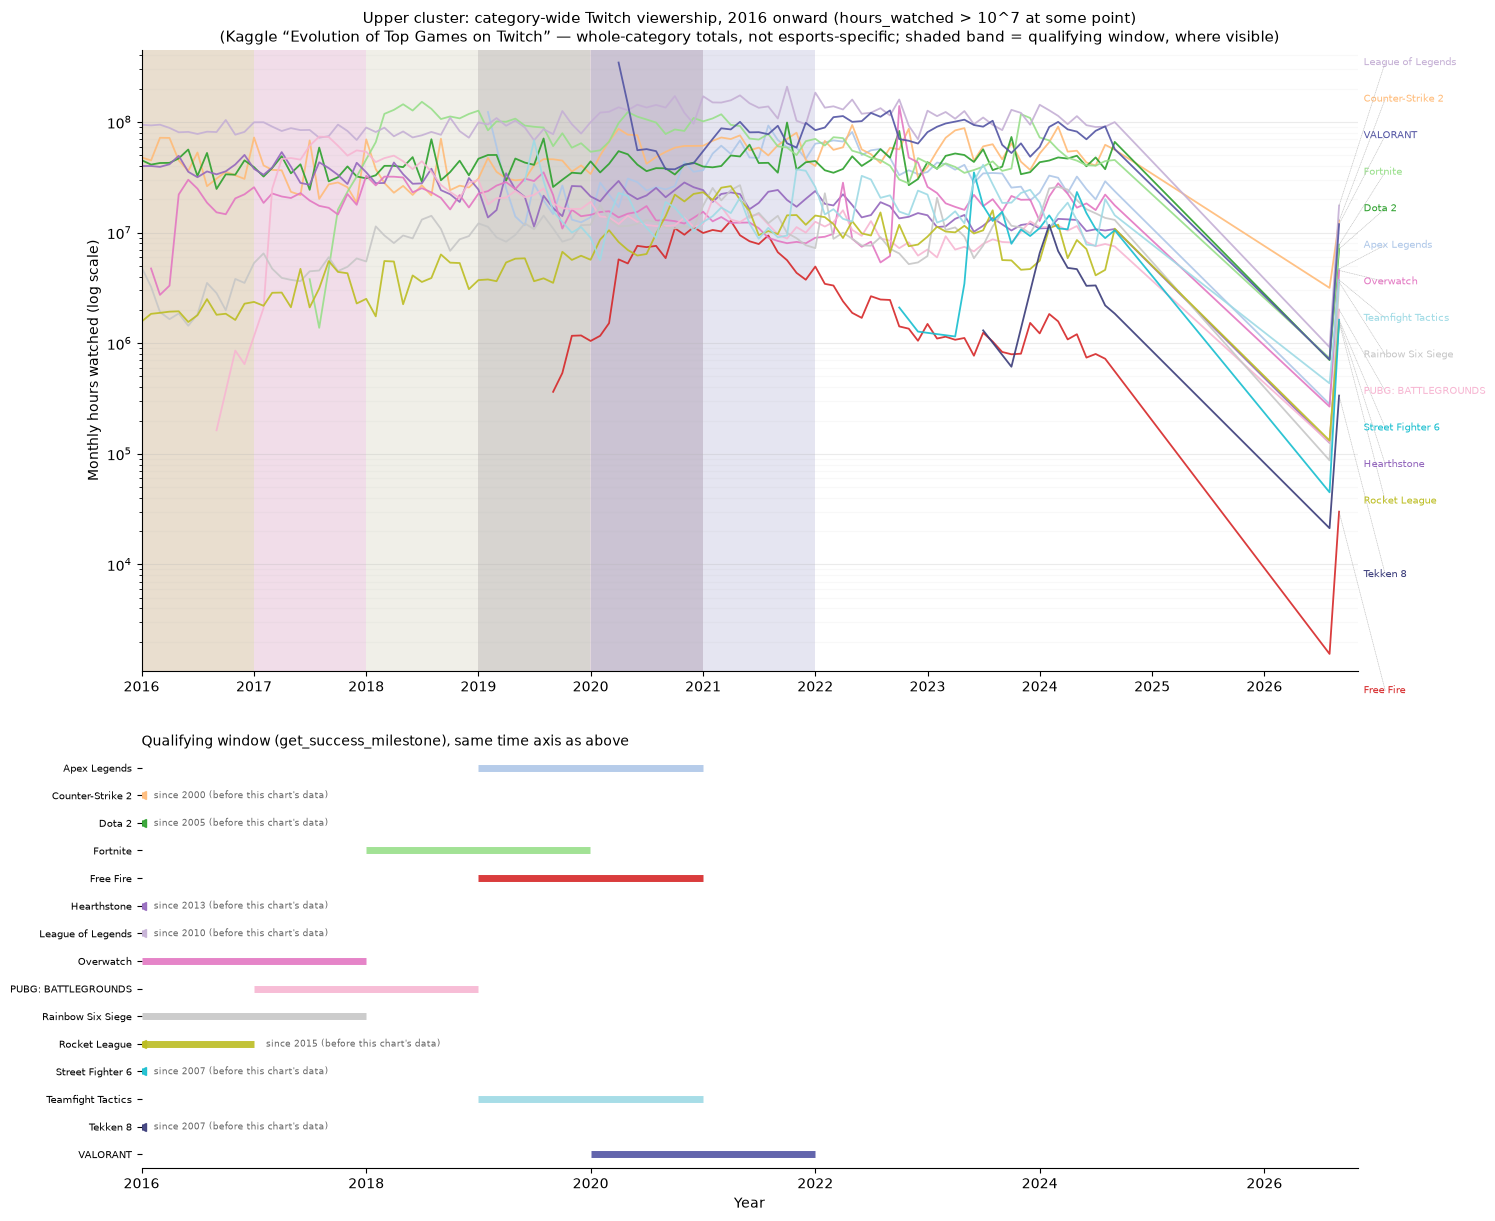

In [6]:
fig_upper = render_cluster_chart(
    upper_cluster,
    "Upper cluster: category-wide Twitch viewership, 2016 onward (hours_watched > 10^7 at some point)\n"
    "(Kaggle “Evolution of Top Games on Twitch” — whole-category totals, not esports-specific; "
    "shaded band = qualifying window, where visible)",
)
plt.show()

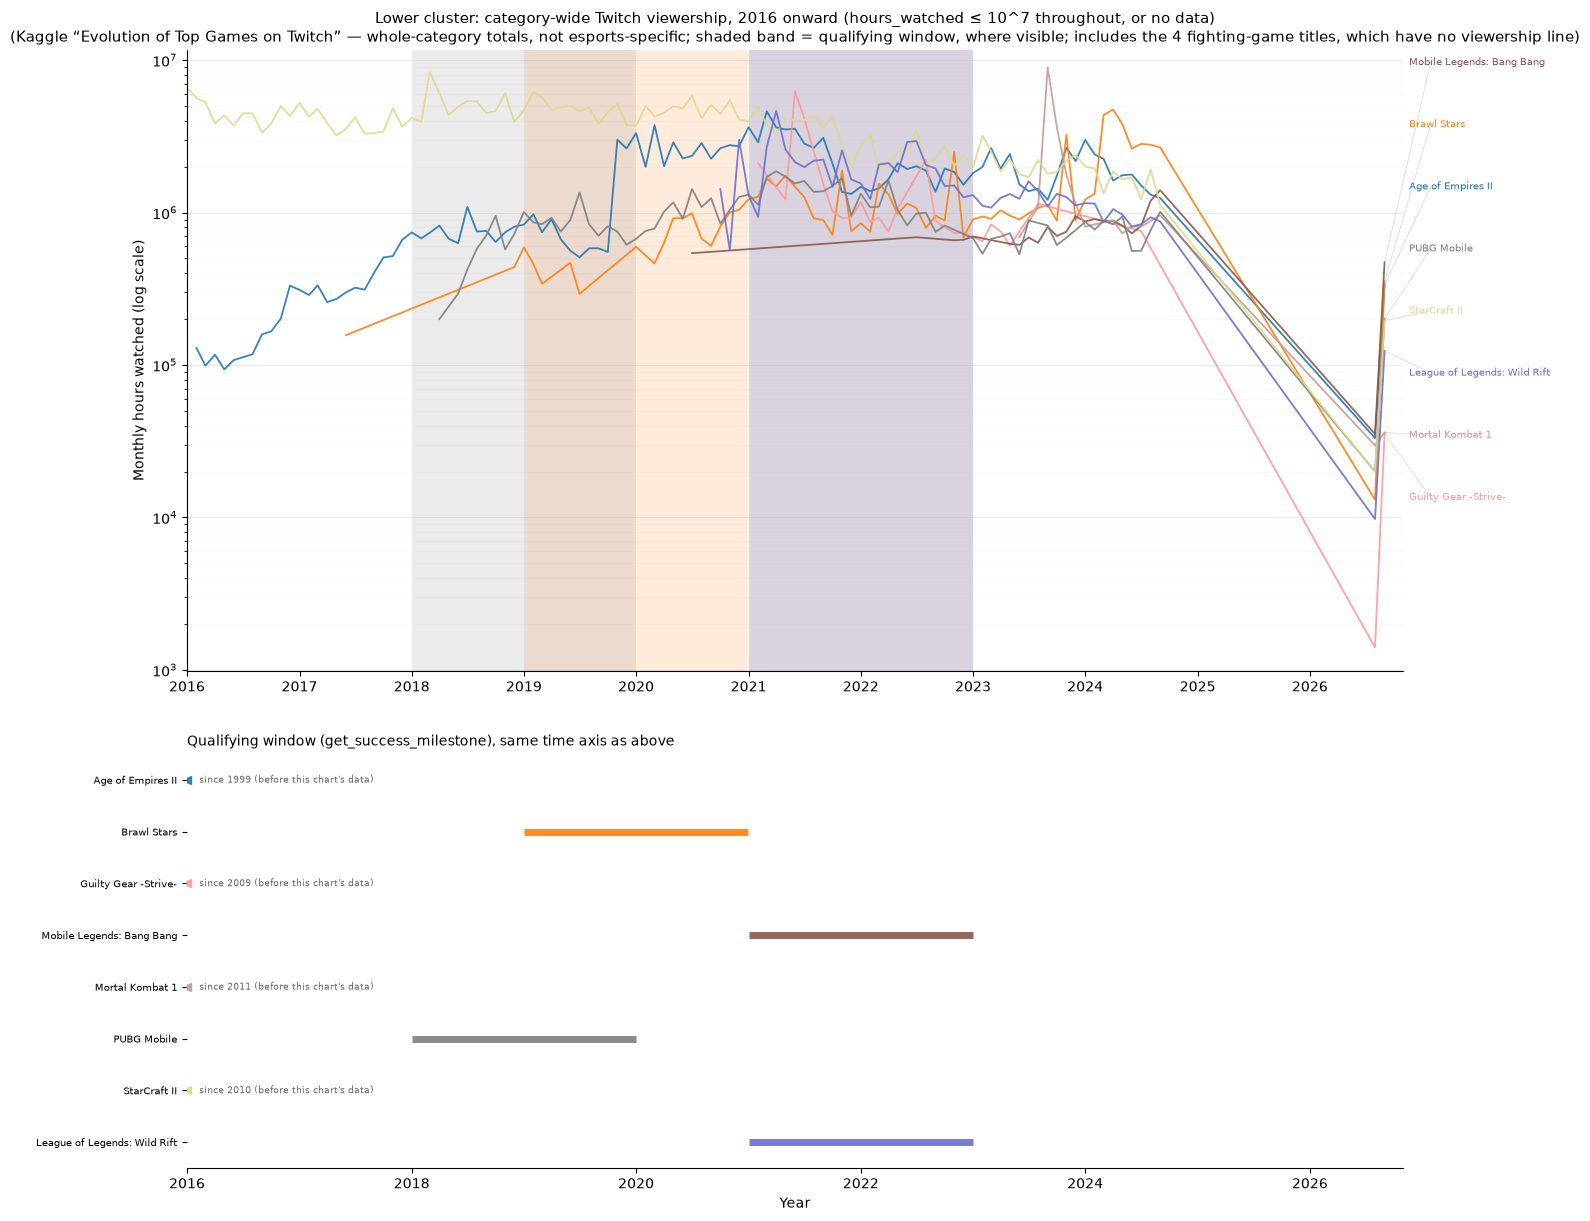

In [7]:
fig_lower = render_cluster_chart(
    lower_cluster,
    "Lower cluster: category-wide Twitch viewership, 2016 onward (hours_watched ≤ 10^7 throughout, or no data)\n"
    "(Kaggle “Evolution of Top Games on Twitch” — whole-category totals, not esports-specific; "
    "shaded band = qualifying window, where visible; includes the 4 fighting-game titles, which have no viewership line)",
)
plt.show()

## Year-over-year growth rate, 2016-2024

Computed, not just eyeballed off the charts above: each title's annual
`hours_watched` total (sum of its available months in that calendar
year), then percent change year over year. **2024 is a partial year** —
the Kaggle dataset ends 2024-09, so 2024's total is Jan-Sep only (9
months) and its YoY figure compares a 9-month total against 2023's full
12 months. Flagged explicitly in the `months_present` column rather than
presented as a comparable full-year rate. 2016 has no prior year in this
dataset, so its own YoY is blank by construction, not a zero.

In [8]:
annual = monthly_df.copy()
annual["year"] = annual["month"].dt.year

annual_totals = (
    annual.groupby(["title_id", "year"])
    .agg(hours_watched=("hours_watched", "sum"), months_present=("month", "nunique"))
    .reset_index()
    .sort_values(["title_id", "year"])
)
annual_totals["yoy_pct"] = annual_totals.groupby("title_id")["hours_watched"].pct_change() * 100

yoy_pivot = annual_totals.pivot(index="title_id", columns="year", values="yoy_pct").round(1)
yoy_pivot.index = [display_name_by_id[t] for t in yoy_pivot.index]
yoy_pivot = yoy_pivot.sort_index()

months_pivot = annual_totals.pivot(index="title_id", columns="year", values="months_present")
partial_years = months_pivot.columns[(months_pivot < 12).any()].tolist()
print(f"Partial year(s) in this data (fewer than 12 months present for at least one title): {partial_years}")

yoy_pivot

Partial year(s) in this data (fewer than 12 months present for at least one title): [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2026]


year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2026
Age of Empires II,NaN,194.9,102.2,38.3,153.7,10.5,-41.5,11.7,-26.5,-97.8
Apex Legends,NaN,NaN,NaN,NaN,-7.9,115.5,-4.5,-39.2,-40.2,-97.9
Brawl Stars,NaN,NaN,180.1,390.5,301.7,76.8,-11.9,2.8,90.3,-98.6
Counter-Strike 2,NaN,-20.2,-4.3,14.0,55.9,7.5,-8.8,-0.5,-25.5,-96.9
Dota 2,NaN,-9.4,5.0,6.5,-1.2,16.4,-8.0,3.5,-23.2,-98.2
Fortnite,NaN,NaN,1565.4,-22.4,1.2,-9.4,-35.8,-0.6,-25.6,-98.2
Free Fire,NaN,NaN,NaN,NaN,2208.1,32.2,-70.6,-55.5,-29.0,-99.7
Guilty Gear -Strive-,NaN,NaN,NaN,NaN,NaN,NaN,-48.2,-62.8,-81.0,-95.1
Hearthstone,NaN,-6.6,-19.2,-30.0,12.9,-11.4,-17.7,-29.1,-29.1,-98.3
League of Legends,NaN,-1.3,-3.6,13.5,38.9,11.7,-10.3,-15.0,-26.9,-98.1


## The Counter-Strike dip around 2023 — checked, and it was a real bug, not a real dip

The upper-cluster chart's Counter-Strike line briefly looked like it
cratered to near-zero in March, April, and September 2023 in an earlier
draft. Checked directly against the raw Kaggle CSV rather than guessing
from the shape: those three months each have **two rows** mapping to
`counter_strike` —

| year_month | rows found |
|---|---|
| 2023-03 | "Counter-Strike: Global Offensive" (65.8M) **+** "Counter-Strike 2" (6.1M) |
| 2023-04 | "Counter-Strike: Global Offensive" (81.0M) **+** "Counter-Strike 2" (2.9M) |
| 2023-09 | "Counter-Strike" (45.0M) **+** "Counter-Strike 2" (0.9M) |

This lines up with the real CS2 launch timeline, not a category-ID
mistake in the source data: Valve ran a **CS2 Limited Test** starting
March 2023 (explaining the small "Counter-Strike 2" rows appearing
alongside the still-dominant CS:GO numbers in March/April), the base
category was renamed from "Counter-Strike: Global Offensive" to plain
"Counter-Strike" sometime before June 2023 (explaining the name change
even before the real relaunch), and CS2 fully replaced CS:GO for everyone
on **2023-09-27** (explaining the last "Counter-Strike 2" row, September,
right at the transition month).

The actual bug was on our side: `collectors/kaggle_import.py`'s original
`INSERT ... ON CONFLICT DO UPDATE` silently **overwrote** one row with the
other whenever two raw Kaggle rows mapped to the same `(title_id,
year_month)`, rather than combining them — and the smaller "Counter-Strike
2" row happened to load last, clobbering the real total down to a few
million. Same shape of bug independently confirmed for **Overwatch** (the
Overwatch 2 beta coexisted with "Overwatch" for 4 months before OW2's Oct
2022 launch) and **Age of Empires II** ("Age of Empires II: Definitive
Edition" vs. plain "Age of Empires II" naming, 2 months) — 9 collisions
total across the whole dataset, all now fixed. `collectors/kaggle_import.py`
now aggregates in memory before writing: `hours_watched`/`avg_viewers`
summed (both categories' viewers are real, concurrent audience), `peak_viewers`
maxed, not summed (the two categories' peaks almost certainly didn't
occur at the same instant, so summing them would overstate a peak that
never actually happened). Validated against known real dates, not just
"the shape looks better now": the corrected Overwatch series peaks
exactly at October 2022 (139M hours) — the actual OW2 launch month — and
Age of Empires II jumps sharply at November 2019 — the actual Definitive
Edition release date.

In [9]:
# Reproducible check, not just a claim: counter_strike's 2023 series after
# the collision fix — no near-zero months left.
cs_2023 = monthly_df[
    (monthly_df["title_id"] == "counter_strike") & (monthly_df["month"].dt.year == 2023)
][["year_month", "hours_watched"]].reset_index(drop=True)
cs_2023

,year_month,hours_watched
0,2023-01,39153067.0
1,2023-02,54680222.0
2,2023-03,71972070.0
3,2023-04,83946046.0
4,2023-05,87965792.0
5,2023-06,44628452.0
6,2023-07,60158134.0
7,2023-08,62909824.0
8,2023-09,45918898.0
9,2023-10,64312173.0
